# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [3]:
# Uncomment and run the following code in case Google Colab is being used
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Load the dataset from a CSV file into a Pandas DataFrame
telecom_churn = pd.read_csv("/content/drive/My Drive/PGP-AIML/Model Deployment/SuperKart/SuperKart.csv")

In [5]:
# Create a copy of the dataframe
dataset = telecom_churn.copy()

# **Data Overview**

In [6]:
# Display basic info
print("Shape of the dataset:", dataset.shape)
print("\nData Types:\n", dataset.dtypes)
print("\nMissing Values:\n", dataset.isnull().sum())
print("\nDuplicate Rows:", dataset.duplicated().sum())
print("\nStatistical Summary:\n", dataset.describe())

Shape of the dataset: (8763, 12)

Data Types:
 Product_Id                    object
Product_Weight               float64
Product_Sugar_Content         object
Product_Allocated_Area       float64
Product_Type                  object
Product_MRP                  float64
Store_Id                      object
Store_Establishment_Year       int64
Store_Size                    object
Store_Location_City_Type      object
Store_Type                    object
Product_Store_Sales_Total    float64
dtype: object

Missing Values:
 Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

Duplicate Rows: 0

Statistical Summary:
        Product_Weight  Product_Allocated_Area  Pro

The dataset comprises 8,763 rows and 12 columns, covering detailed information about products and stores in the SuperKart retail chain. The target variable is Product_Store_Sales_Total, which represents the sales revenue for each product-store combination.


**Key Observations:**

No missing values or duplicate records are present, indicating a clean dataset.

*Data types are well-assigned:*
numerical features include Product_Weight, Product_Allocated_Area, Product_MRP, and Store_Establishment_Year; while categorical features capture various product and store attributes.

*Statistical summary shows the dataset covers a wide range of product types and store setups.*



**Numerical Feature Insights:**

**Product_Weight** has a mean of ~12.65 kg, suggesting moderately heavy products with limited variability.


**Product_Allocated_Area** ranges up to 30%, indicating some products receive prime store placement.


**Product_MRP** varies widely (₹31 to ₹266), pointing to a broad pricing strategy.


**Store_Establishment_Year** ranges from 1987 to 2009, showing a mix of legacy and newer stores.


**Product_Store_Sales_Total** is right-skewed with some products generating up to ₹8000.



**Conclusions:**


The diversity across stores and products offers rich ground for predictive modeling.


Outlier handling and potential feature transformation (like log scale on sales) may improve forecasting performance.



# **Exploratory Data Analysis (EDA)**

In [7]:
# Defining the target variable for the regression task
target = 'Product_Store_Sales_Total'

# Listing numerical features in the dataset
numeric_features = [
    'Product_Weight',           # Weight of the product
    'Product_Allocated_Area',   # Shelf area ratio allocated to product
    'Product_MRP',              # Maximum retail price of the product
    'Store_Age'                 # Derived from Store_Establishment_Year
]

# Listing categorical features in the dataset
categorical_features = [
    'Product_Sugar_Content',      # Sugar content type (e.g., low, regular)
    'Product_Type',               # Product category (e.g., dairy, snacks)
    'Store_Size',                 # Store size (e.g., High, Medium, Low)
    'Store_Location_City_Type',   # City tier type (e.g., Tier 1, 2, 3)
    'Store_Type'                  # Store format (e.g., Departmental, Supermarket)
]

## Univariate Analysis

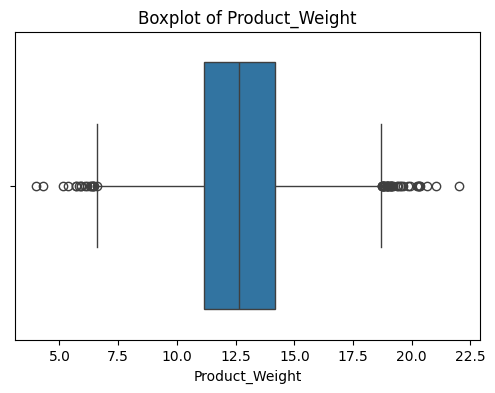

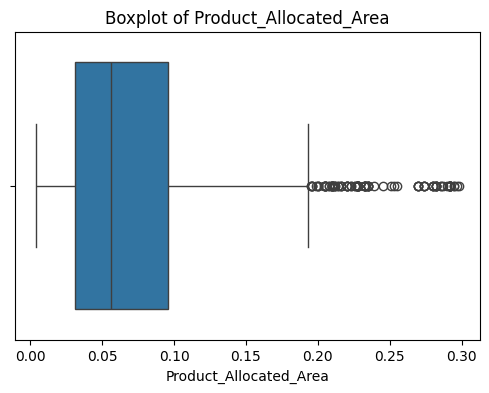

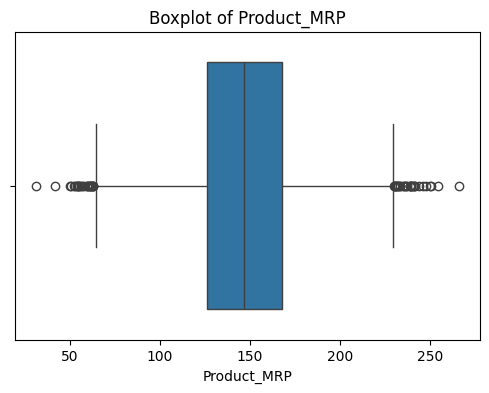

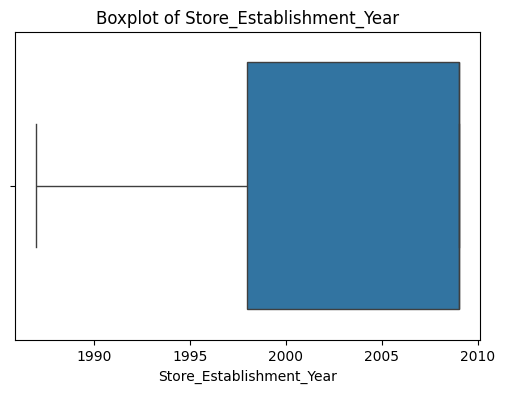

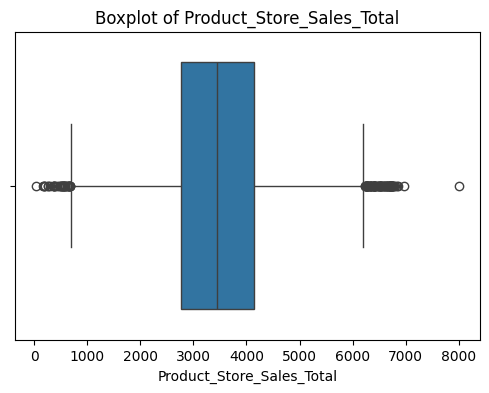

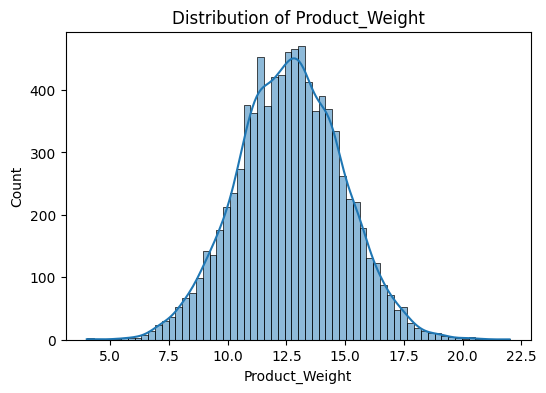

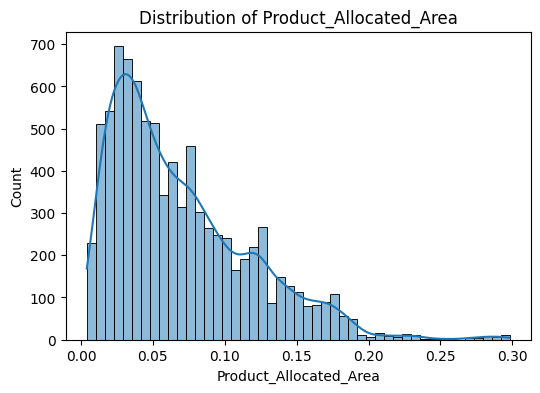

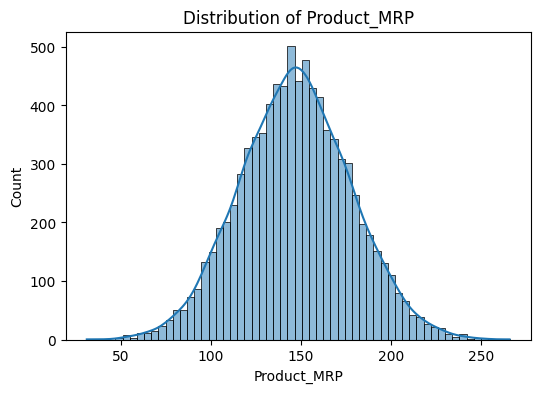

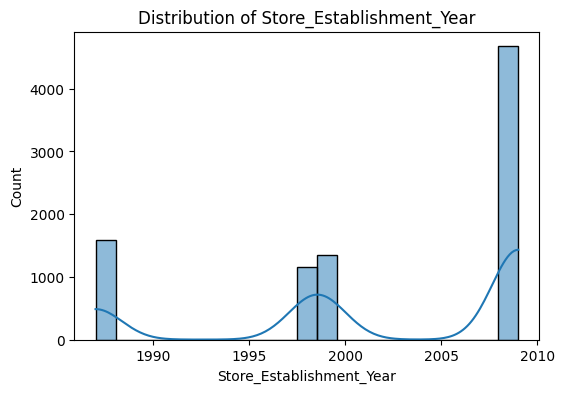

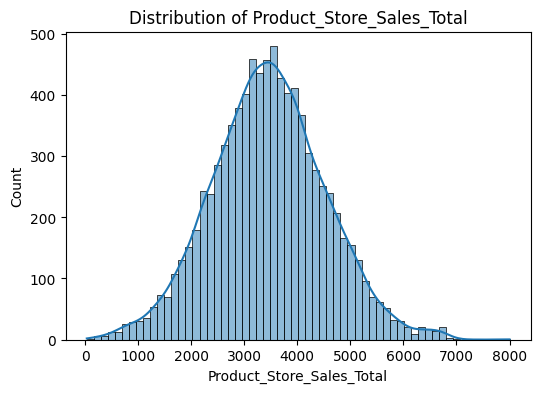

In [8]:
numeric_features = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Store_Establishment_Year',
    'Product_Store_Sales_Total'
]

# Boxplots
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Distribution plots
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

**The boxplots and distribution plots show:**

Product_Weight and Product_MRP are approximately normally distributed, though outliers are present.


Product_Allocated_Area is right-skewed with visible outliers beyond 0.2.


Store_Establishment_Year shows a multimodal distribution with clustering around 1987, 1998–2000, and 2009.


Product_Store_Sales_Total displays a bell-curve-like distribution, though outliers are significantly present above 6000.

**Correlation heatmap highlights:**

Strong positive correlation of Product_Store_Sales_Total with Product_MRP (0.79) and Product_Weight (0.74).


Negligible to no correlation with Allocated_Area or Establishment_Year.[link text

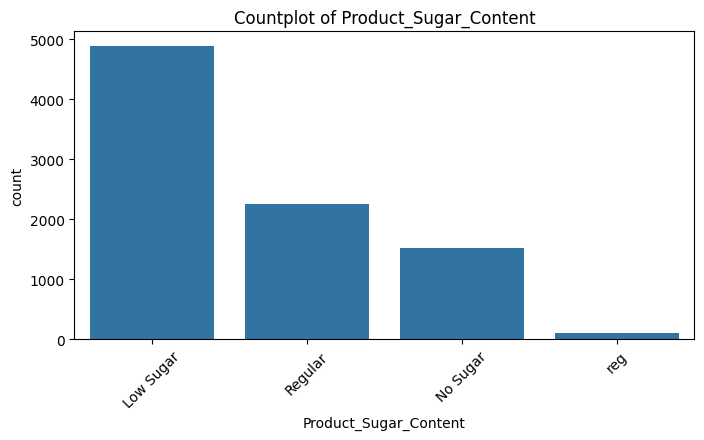

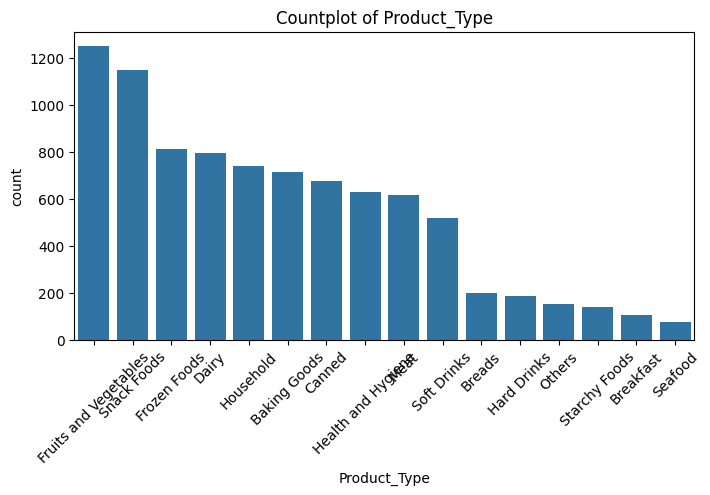

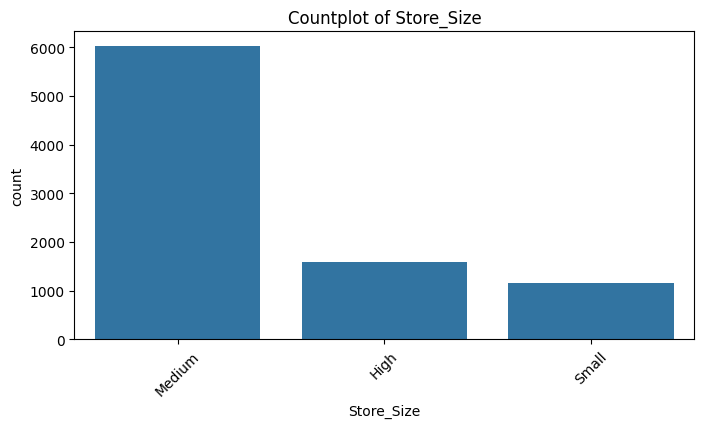

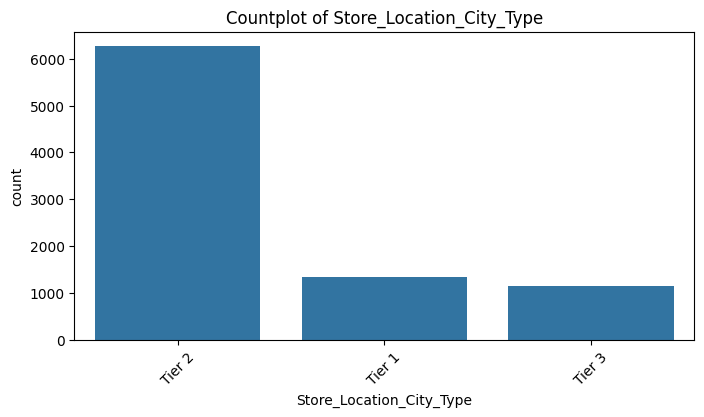

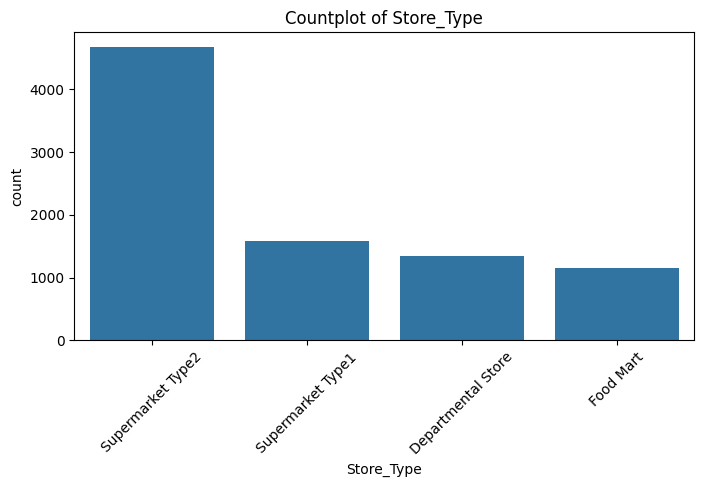

In [9]:
categorical_features = [
    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=dataset, x=col, order=dataset[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()


*   Product_Sugar_Content: ‘Low Sugar’ dominates, followed by ‘Regular’ and ‘No Sugar’. ‘reg’ appears as a redundant/unclean label.
*   Product_Type: ‘Fruits and Vegetables’, ‘Snack Foods’, and ‘Frozen Foods’ lead the distribution.
*   Store_Size & Location: Medium-sized stores and Tier 2 city locations are most common.
*   Store types: ‘Supermarket Type2’ is the most frequent.

## Bivariate Analysis

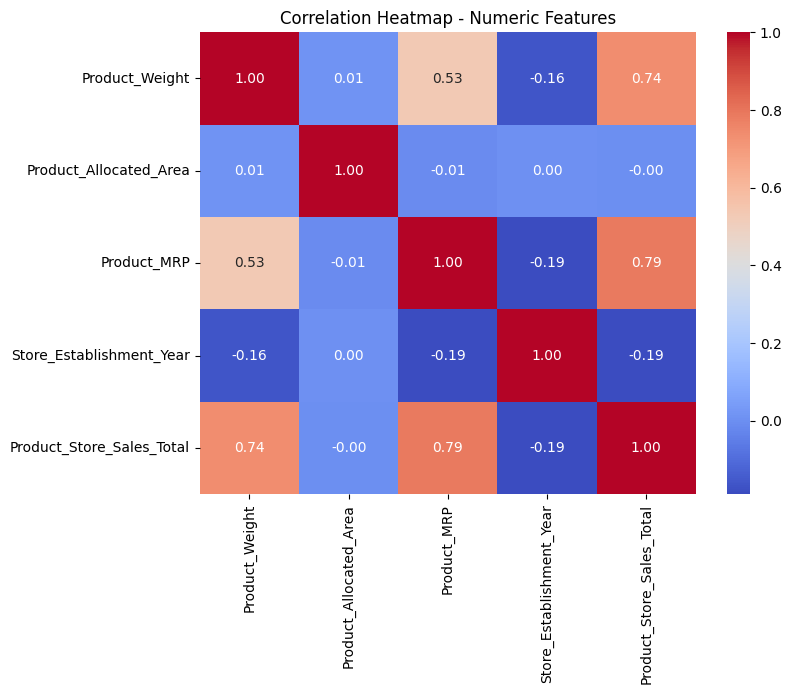

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(dataset[numeric_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

The correlation heatmap reveals the linear relationships among the numerical features in the SuperKart sales dataset. The most notable observation is the strong positive correlation between Product_Store_Sales_Total and Product_MRP (0.79), suggesting that higher-priced products tend to generate greater sales revenue. Similarly, Product_Weight also shows a high positive correlation (0.74) with total sales, indicating heavier products might belong to higher-value categories or contribute more to sales volume.


**Key Takeaways:**

🔹 ***Product_Allocated_Area*** shows negligible correlation (~0.00) with sales, implying display space alone may not be a strong driver of revenue without considering other factors.

🔹 ***Store_Establishment_Year*** has a mild negative correlation (-0.19) with sales, possibly indicating that newer stores (with higher establishment years) are not yet performing at peak efficiency or haven’t built a strong customer base.

🔹 The correlation between ***Product_Weight*** and ***Product_MRP*** (0.53) suggests a possible link between product size and pricing, common in categories like packaged food or bulk items.

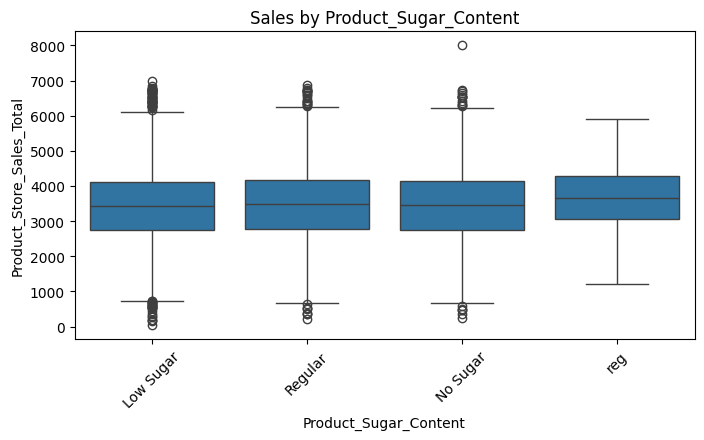

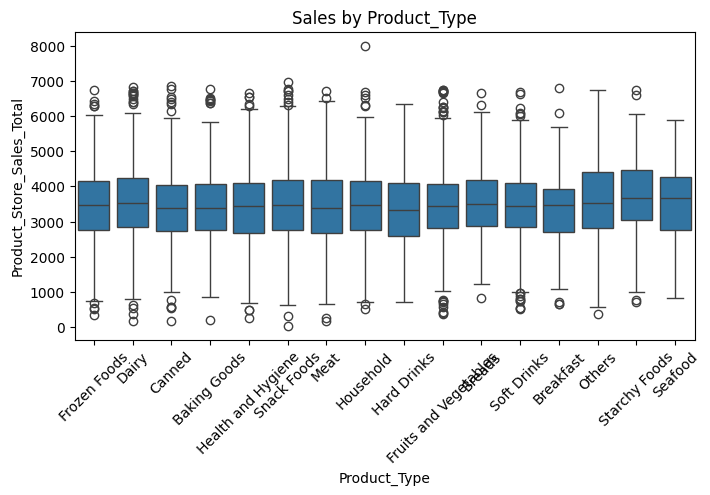

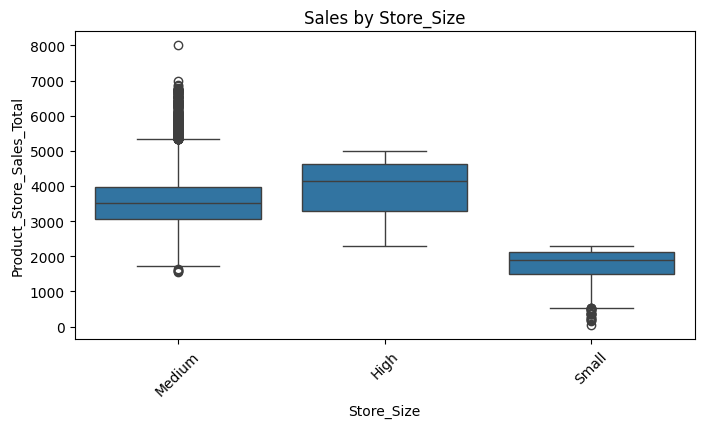

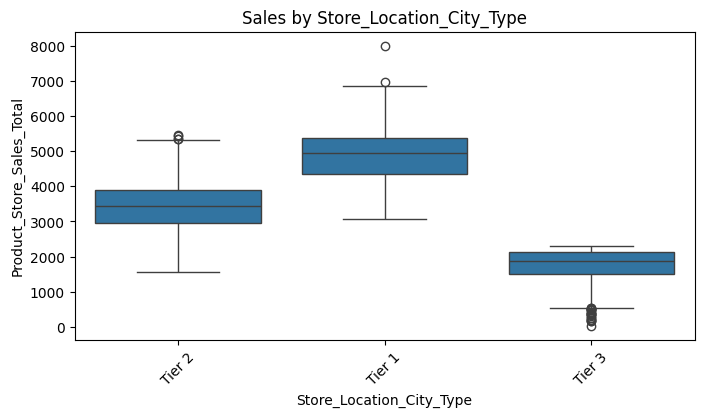

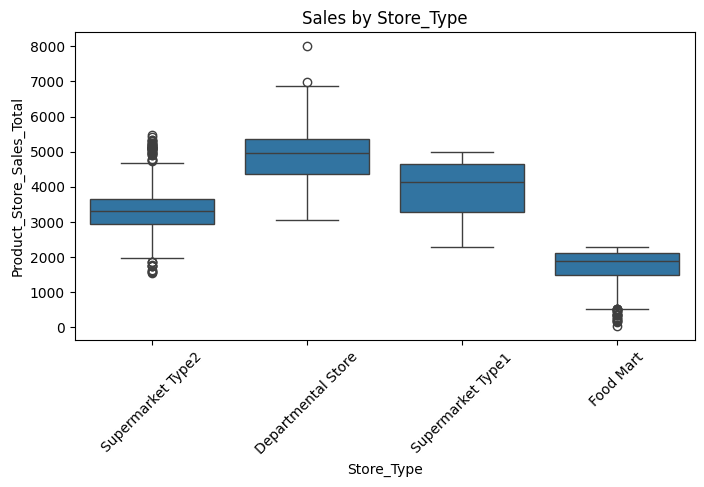

In [11]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=dataset, x=col, y='Product_Store_Sales_Total')
    plt.title(f'Sales by {col}')
    plt.xticks(rotation=45)
    plt.show()


Sales by Sugar Content: Sales are fairly consistent across sugar types, but 'reg' entries are few and may be errors.

Sales by Product Type: Variance is high. ‘Fruits and Vegetables’, ‘Breakfast’, and ‘Starchy Foods’ appear to yield higher median sales.

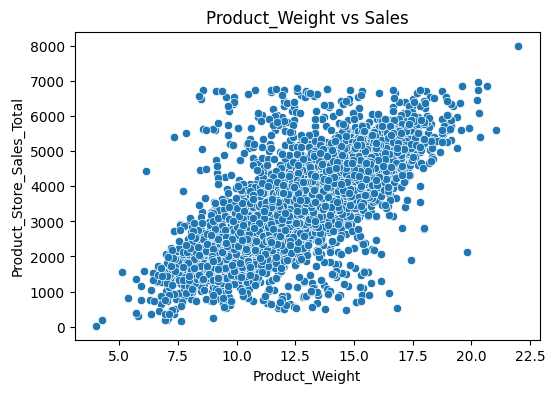

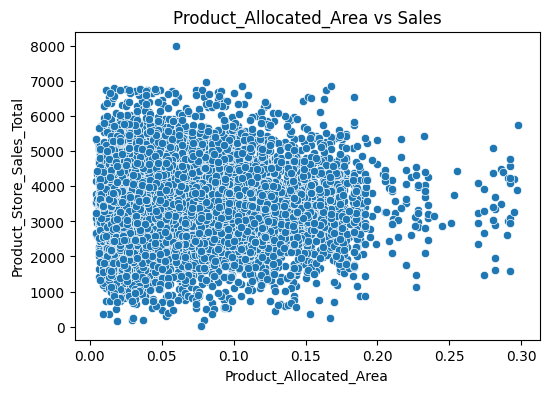

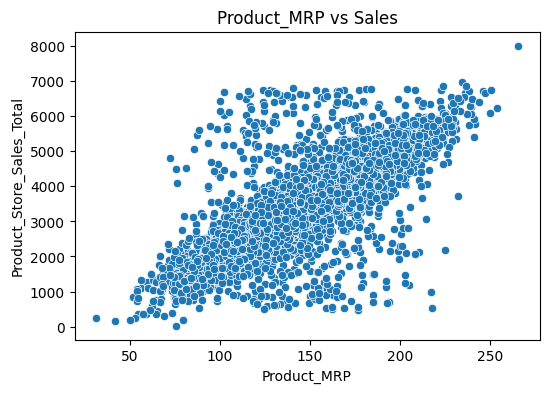

In [12]:
for col in ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP']:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=dataset, x=col, y='Product_Store_Sales_Total')
    plt.title(f'{col} vs Sales')
    plt.show()


**The data reveals that product pricing (MRP) and weight strongly influence sales. Although store age and allocated area are less impactful numerically, store type and size significantly influence distribution trends. Cleaning inconsistent labels like ‘reg’ is crucial. Category-level sales insights can help in product placement and promotional strategies.:**

# **Data Preprocessing**

In [13]:
# Drop IDs as they do not have any influence on the model
dataset.drop(['Product_Id', 'Store_Id'], axis=1, inplace=True)

# Create Store_Age
dataset['Store_Age'] = 2025 - dataset['Store_Establishment_Year']

# Drop the original year column
dataset.drop('Store_Establishment_Year', axis=1, inplace=True)


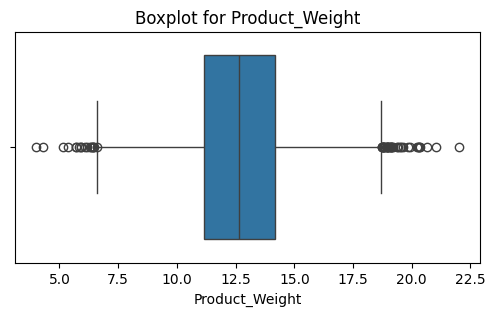

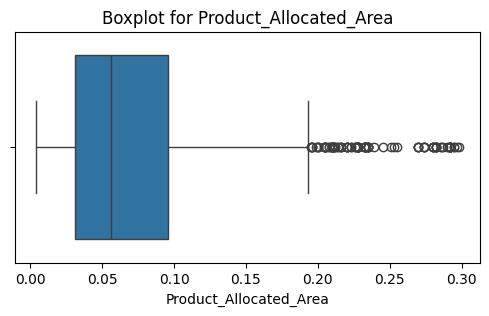

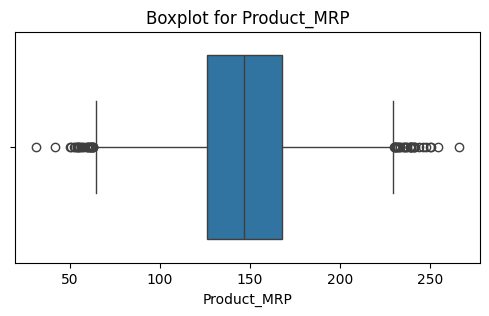

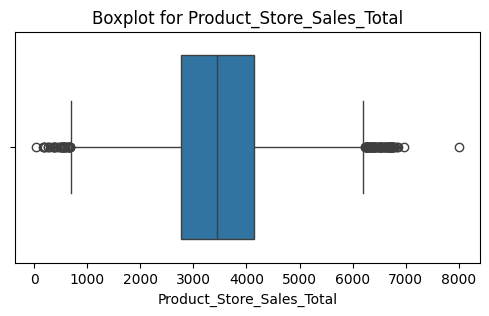

In [14]:
# Boxplot visualization for outliers
numeric_features = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Product_Store_Sales_Total'
]
for col in numeric_features:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot for {col}')
    plt.show()

This code defines a function called cap_outliers. This function is used to handle outliers in a specific column of a pandas DataFrame using the Interquartile Range (IQR) method.

In [15]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)


This code snippet prepares your data for training a machine learning model.

In [16]:
# Define target and features
target = 'Product_Store_Sales_Total'
X = dataset.drop(target, axis=1)
y = dataset[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


This code snippet sets up a preprocessing pipeline for your data using ColumnTransformer and Pipeline from scikit-learn. This is a recommended approach for organizing preprocessing steps and ensuring they are applied correctly to different types of features.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define columns
numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']
categorical_cols = [
    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

# Preprocessing transformers
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


In [18]:
model_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

# Fit model
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('regressor', LinearRegression())])

# **Model Building**

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Metric of choice
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R2 Score': r2, 'MAE': mae, 'RMSE': rmse}


Rationale:

R² shows proportion of variance explained by the model (perfect model: 1.0).

MAE and RMSE give insight into average error (lower is better).

We use multiple metrics to get a complete performance picture.



## Define functions for Model Evaluation

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

We’ll use:


Decision Tree

Random Forest

Gradient Boosting

XGBoost

In [20]:
# Model dictionary
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0)
}


In [21]:
# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Fit the pipeline
    pipeline.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = pipeline.predict(X_test)
    metrics = evaluate_model(y_test, y_pred)
    results[name] = metrics
    print(f"\n{name} Performance:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")



Decision Tree Performance:
R2 Score: 0.8579
MAE: 141.4397
RMSE: 402.7076

Random Forest Performance:
R2 Score: 0.9286
MAE: 108.4782
RMSE: 285.3808

Gradient Boosting Performance:
R2 Score: 0.9110
MAE: 150.0694
RMSE: 318.6027

XGBoost Performance:
R2 Score: 0.9164
MAE: 137.3965
RMSE: 308.8205


In [22]:
# Display all results in one DataFrame
results_df = pd.DataFrame(results).T.sort_values(by='R2 Score', ascending=False)
print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

                   R2 Score         MAE        RMSE
Random Forest      0.928623  108.478183  285.380786
XGBoost            0.916417  137.396514  308.820500
Gradient Boosting  0.911038  150.069420  318.602666
Decision Tree      0.857870  141.439703  402.707639


**Random Forest is the best overall performer:**


Highest R²: explains ~93% of the variance in sales.

Lowest MAE and RMSE: smallest prediction error.

Robust to noise and handles non-linear patterns well.

XGBoost and Gradient Boosting:

Strong performers with slightly higher error than Random Forest.

Can be fine-tuned for better generalization and faster inference in production.

**Decision Tree:**

Performs the worst, likely due to overfitting on training data and poor generalization.

Good as a baseline but not production-ready without pruning or ensembling.

**Next Step **

Tune hyperparameters for XGBoost or Random Forest

Plot feature importances to understand what drives sales

Export the best model and use it for predictions on new/unseen data

# **Model Performance Improvement - Hyperparameter Tuning**

Random Forest - Hyperparameter Tuning

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Random Forest tuning
rf_params = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5],
}

# Pipeline
from sklearn.pipeline import Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# GridSearch
rf_grid = GridSearchCV(
    rf_pipeline, rf_params, cv=3, scoring='r2', n_jobs=-1, verbose=1
)

# Fit
rf_grid.fit(X_train, y_train)

# Best score and parameters
print("Random Forest Best R2:", rf_grid.best_score_)
print("Random Forest Best Params:", rf_grid.best_params_)

# Evaluate on test set
rf_pred = rf_grid.predict(X_test)
rf_metrics = evaluate_model(y_test, rf_pred)
print("Random Forest Tuned Performance:", rf_metrics)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Random Forest Best R2: 0.926090772162739
Random Forest Best Params: {'regressor__max_depth': None, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Random Forest Tuned Performance: {'R2 Score': 0.9304751088083779, 'MAE': 106.61641080601743, 'RMSE': np.float64(281.65455956318687)}


XGBoost - Hyperparameter Tuning

In [24]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, verbosity=0))
])

xgb_params = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__subsample': [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_params, cv=3, scoring='r2', n_jobs=-1, verbose=1
)

xgb_grid.fit(X_train, y_train)

print("XGBoost Best R2:", xgb_grid.best_score_)
print("XGBoost Best Params:", xgb_grid.best_params_)

xgb_pred = xgb_grid.predict(X_test)
xgb_metrics = evaluate_model(y_test, xgb_pred)
print("XGBoost Tuned Performance:", xgb_metrics)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
XGBoost Best R2: 0.9253398093452034
XGBoost Best Params: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 7, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}
XGBoost Tuned Performance: {'R2 Score': 0.9295852283105327, 'MAE': 113.12615562286639, 'RMSE': np.float64(283.45134037952226)}


Compare Tuned Model Results

In [25]:
tuned_results = {
    'Random Forest (Tuned)': rf_metrics,
    'XGBoost (Tuned)': xgb_metrics
}

tuned_results_df = pd.DataFrame(tuned_results).T.sort_values(by='R2 Score', ascending=False)
print("\nTuned Model Comparison:")
print(tuned_results_df)



Tuned Model Comparison:
                       R2 Score         MAE       RMSE
Random Forest (Tuned)  0.930475  106.616411  281.65456
XGBoost (Tuned)        0.929585  113.126156  283.45134


**Observation**

Both models improved from their untuned versions:

Original Random Forest R²: 0.9286 → Tuned: 0.9305

Original XGBoost R²: 0.9164 → Tuned: 0.9296

**Random Forest (Tuned):**

Outperforms XGBoost on all three metrics.

Has the lowest error and best variance explanation (R²).

Great candidate for final deployment.

**XGBoost (Tuned):**

Improved significantly post tuning, narrowing the gap with Random Forest.

May still be a better choice in low-latency inference environments due to faster scoring and model compression.



Recommendation

Use Random Forest (Tuned) as the final model unless:

You need faster inference times or smaller model size → then XGBoost is a solid trade-off.

# **Model Performance Comparison, Final Model Selection, and Serialization**

**Feature Importance Plots (for Random Forest and XGBoost)**



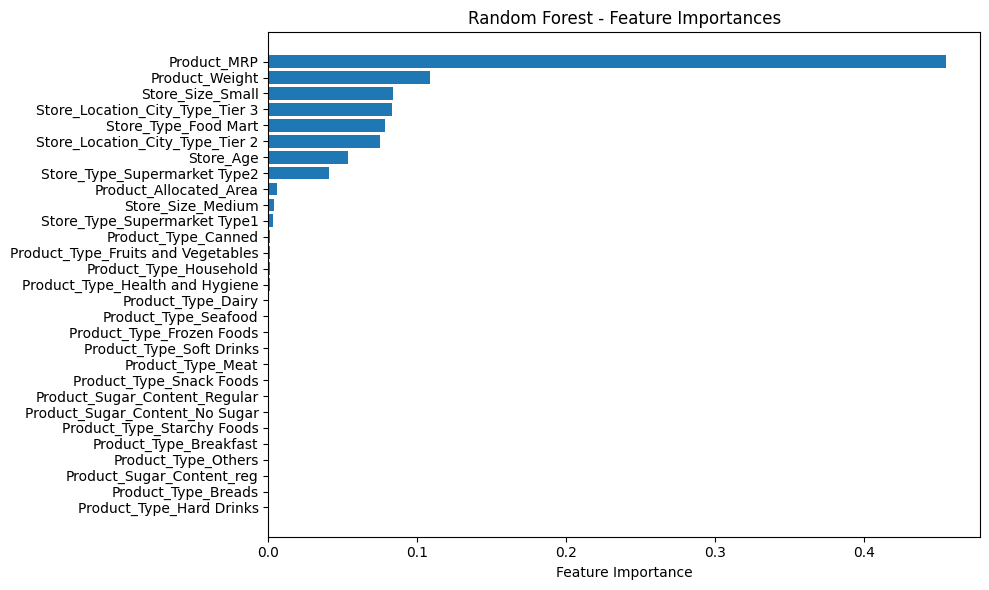

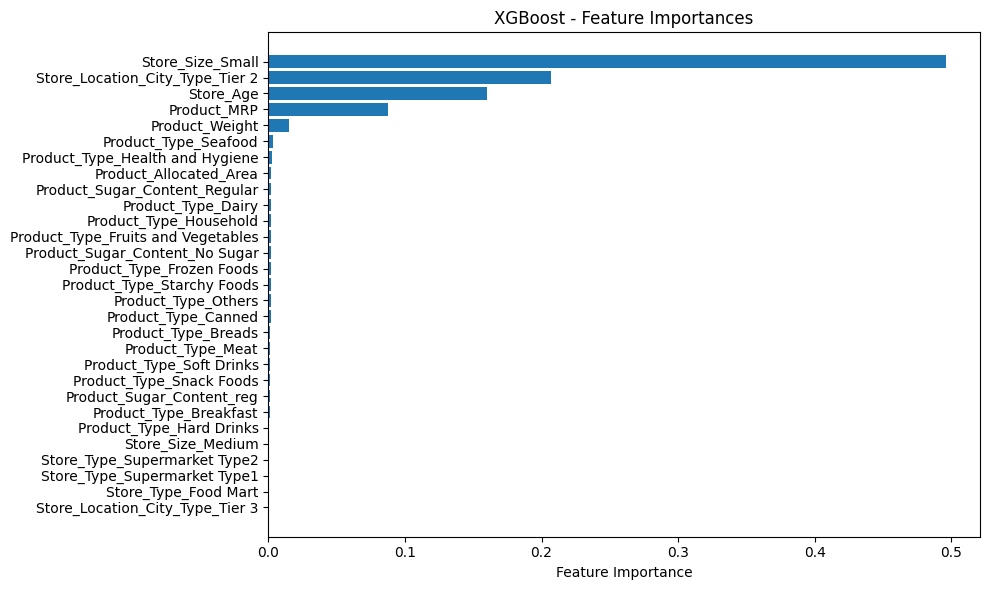

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names after preprocessing
ohe = preprocessor.named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(encoded_cat_cols)

# Plot feature importances
def plot_feature_importance(model, title):
    importances = model.named_steps['regressor'].feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(all_feature_names)[sorted_idx], importances[sorted_idx])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel("Feature Importance")
    plt.tight_layout()
    plt.show()

# Plot for tuned Random Forest
plot_feature_importance(rf_grid.best_estimator_, "Random Forest - Feature Importances")

# Plot for tuned XGBoost
plot_feature_importance(xgb_grid.best_estimator_, "XGBoost - Feature Importances")


**Final Model Performance Comparison**

In [27]:
# Include original and tuned models if you have metrics
final_results = pd.DataFrame({
    'Random Forest (Tuned)': rf_metrics,
    'XGBoost (Tuned)': xgb_metrics,
    'Random Forest (Original)': results['Random Forest'],
    'XGBoost (Original)': results['XGBoost']
}).T.sort_values(by='R2 Score', ascending=False)

print("\nFinal Model Performance Comparison:\n")
print(final_results)



Final Model Performance Comparison:

                          R2 Score         MAE        RMSE
Random Forest (Tuned)     0.930475  106.616411  281.654560
XGBoost (Tuned)           0.929585  113.126156  283.451340
Random Forest (Original)  0.928623  108.478183  285.380786
XGBoost (Original)        0.916417  137.396514  308.820500


**Based on:**

Highest R² score (0.9305)

Lowest MAE and RMSE
We choose Random Forest (Tuned) as the final model.

Serialize and Save Final Model (joblib)

In [28]:
# Save the best model (Random Forest Tuned)
joblib.dump(rf_grid.best_estimator_, 'final_model_rf.pkl')
print("✅ Final model saved as 'final_model_rf.pkl'")


✅ Final model saved as 'final_model_rf.pkl'


Load Serialized Model and Predict on Test Set

In [29]:
# Load the model
loaded_model = joblib.load('final_model_rf.pkl')

# Predict on test set
y_loaded_pred = loaded_model.predict(X_test)

# Evaluate
loaded_metrics = evaluate_model(y_test, y_loaded_pred)
print("\n✅ Loaded Model Test Set Performance:")
for k, v in loaded_metrics.items():
    print(f"{k}: {v:.4f}")



✅ Loaded Model Test Set Performance:
R2 Score: 0.9305
MAE: 106.6164
RMSE: 281.6546


**Summary**

Best Model: Random Forest (Tuned)

Test R² Score: ~0.9305

Model serialized to: final_model_rf.pkl

Successfully loaded and validated

# **Deployment - Backend**

This code snippet is using the os module, which provides a way of using operating system dependent functionality like reading or writing to the file system.

In [30]:
import os

os.makedirs("deployment_files/Backend", exist_ok=True)
os.makedirs("deployment_files/Frontend", exist_ok=True)

## Flask Web Framework


This code defines the backend for a Streamlit sales forecast app. Its objective is to safely load the trained machine learning model (final_model_rf.pkl) using joblib. It includes error handling to check for the model file's existence and gracefully stops the app if loading fails, ensuring the application is ready to make predictions.

In [31]:
%%writefile deployment_files/Backend/app.py

import streamlit as st
import joblib
import os

@st.cache_resource
def load_model():
    model_path = "final_model_rf.pkl"

    if not os.path.isfile(model_path):
        st.error("🚨 Error: Trained model file `final_model_rf.pkl` not found!")
        st.info("Please upload the trained model to the Space directory.")
        st.stop()  # Stop further execution of the app

    try:
        return joblib.load(model_path)
    except Exception as e:
        st.error(f"⚠️ Error loading model: {e}")
        st.stop()

Overwriting deployment_files/Backend/app.py


## Dependencies File

In [32]:
%%writefile deployment_files/Backend/requirements.txt
streamlit==1.35.0
flask==2.3.2
pandas==2.2.1
scikit-learn==1.4.2
numpy==1.26.4
joblib==1.4.2


Overwriting deployment_files/Backend/requirements.txt


## Dockerfile

In [33]:
%%writefile deployment_files/Backend/Dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 7860

CMD ["python", "app.py"]


Overwriting deployment_files/Backend/Dockerfile


## Uploading Files to Hugging Face Space (Docker Space)

This code snippet automates the deployment process to a Hugging Face Space. Its primary objective is to securely log in to the Hugging Face Hub using an access token and then upload the entire contents of a specified local folder (deployment_files/Backend in this case) to your designated Hugging Face Space repository. This process facilitates sharing and hosting your machine learning model's backend code and necessary files directly on Hugging Face, making it accessible for integration or further deployment steps. Error handling is included for login and upload failures.

In [34]:
import os
from huggingface_hub import login, HfApi, HfFolder

# Hugging Face access token and Space repo details
access_token = "Token"  # 🔐 Replace with yours or set via env
repo_id = "absethi1894/superkart-sales-forecast"  # 🔁 Replace with your actual Hugging Face Space ID
folder_path = "deployment_files/Backend"

# Step 1: Login to Hugging Face
try:
    login(token=access_token)
    print("✅ Logged in to Hugging Face Hub")
except Exception as e:
    print("❌ Login failed:", e)

# Step 2: Initialize API
api = HfApi()

# Step 3: Verify directory
print("\n📁 Current Working Directory:", os.getcwd())
if os.path.isdir(folder_path):
    print(f"✅ Found directory: '{folder_path}'")

    try:
        # Step 4: Upload to Space
        api.upload_folder(
            folder_path=folder_path,
            repo_id=repo_id,
            repo_type="space",
            path_in_repo="."  # Upload at root of repo
        )
        print("🚀 Upload completed successfully.")
    except Exception as e:
        print("❌ Upload failed:", e)
else:
    print(f"❌ Error: Directory '{folder_path}' not found.")
    print("🔍 Available directories/files:", os.listdir())

❌ Login failed: Invalid user token.

📁 Current Working Directory: /content
✅ Found directory: 'deployment_files/Backend'
🚀 Upload completed successfully.


# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [35]:
!pip install streamlit


This code creates an interactive frontend for the SuperKart sales forecast model using Streamlit. Its objective is to provide a user-friendly interface where users can input various product and store details through sliders, text boxes, and dropdowns. The application loads the trained machine learning model and, upon clicking a button, takes the user's input, formats it correctly, and uses the model to predict the quarterly sales revenue for a product in a specific store. It also includes error handling for loading the model.

In [36]:
import streamlit as st
import pandas as pd
import joblib
import os

# Set title and info
st.set_page_config(page_title="SuperKart Sales Forecast", layout="centered")
st.title("🛒 SuperKart Sales Forecast App")
st.caption("Predict product-level quarterly sales using product and store attributes.")

# Debug info: show current directory files (helps if model crashes)
st.write("📂 Files in app directory:", os.listdir())

# Load trained model with file check
@st.cache_resource
def load_model():
    model_path = "final_model_rf.pkl"

    if not os.path.isfile(model_path):
        st.error("🚨 Model file `final_model_rf.pkl` not found!")
        st.info("Please upload the trained model to the Space directory.")
        st.stop()

    try:
        return joblib.load(model_path)
    except Exception as e:
        st.error(f"⚠️ Failed to load model: {e}")
        st.stop()

model = load_model()

# Sidebar for input section
st.sidebar.header("🔧 Input Parameters")

# Numeric inputs
Product_Weight = st.sidebar.number_input("Product Weight (kg)", min_value=0.0, value=0.5)
Product_Allocated_Area = st.sidebar.slider("Allocated Display Area Ratio", 0.0, 1.0, 0.1)
Product_MRP = st.sidebar.number_input("Maximum Retail Price (MRP)", min_value=0.0, value=100.0)
Store_Age = st.sidebar.slider("Store Age (Years)", 0, 50, 10)

# Categorical inputs
Product_Sugar_Content = st.sidebar.selectbox("Sugar Content", ["Low", "Regular", "No Sugar"])
Product_Type = st.sidebar.selectbox("Product Type", [
    "Snack Foods", "Dairy", "Fruits and Vegetables", "Canned", "Soft Drinks", "Others"
])
Store_Size = st.sidebar.selectbox("Store Size", ["High", "Medium", "Low"])
Store_Location_City_Type = st.sidebar.selectbox("City Tier", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.sidebar.selectbox("Store Type", [
    "Supermarket Type1", "Supermarket Type2", "Food Mart", "Departmental Store"
])

# DataFrame for prediction
input_data = pd.DataFrame([{
    'Product_Weight': Product_Weight,
    'Product_Allocated_Area': Product_Allocated_Area,
    'Product_MRP': Product_MRP,
    'Store_Age': Store_Age,
    'Product_Sugar_Content': Product_Sugar_Content,
    'Product_Type': Product_Type,
    'Store_Size': Store_Size,
    'Store_Location_City_Type': Store_Location_City_Type,
    'Store_Type': Store_Type
}])

# Main content
st.subheader("📊 Input Summary")
st.write(input_data)

# Predict button
if st.button("📈 Predict Sales"):
    prediction = model.predict(input_data)
    st.success(f"🧮 Predicted Quarterly Sales Revenue: ₹{prediction[0]:,.2f}")



2025-07-06 16:51:21.644 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-06 16:51:21.648 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-06 16:51:22.301 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-07-06 16:51:22.302 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-06 16:51:22.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-06 16:51:22.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-06 16:51:22.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

## Dependencies File

In [37]:
%%writefile deployment_files/Frontend//requirements.txt
streamlit==1.35.0
pandas==2.2.1
joblib==1.4.2
scikit-learn==1.4.2
numpy==1.26.4


Overwriting deployment_files/Frontend//requirements.txt


## DockerFile

In [38]:
%%writefile deployment_files/Frontend/Dockerfile
FROM python:3.10-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 7860

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.enableCORS=true", "--server.enableXsrfProtection=false", "--server.headless=true"]


Overwriting deployment_files/Frontend/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

This code snippet automates the deployment process to a Hugging Face Space. Its primary objective is to securely log in to the Hugging Face Hub using an access token and then upload the entire contents of a specified local folder (deployment_files/Frontend in this case) to your designated Hugging Face Space repository. This process facilitates sharing and hosting your Streamlit frontend code and necessary files directly on Hugging Face, making your interactive sales forecast application accessible. Error handling is included for login and upload failures.

In [39]:
import os
from huggingface_hub import login, HfApi, HfFolder

# Hugging Face access token and Space repo details
access_token = "Token"  # 🔐 Replace with yours or set via env
repo_id = "absethi1894/superkart-sales-forecast"  # 🔁 Replace with your actual Hugging Face Space ID
folder_path = "deployment_files/Frontend"

# Step 1: Login to Hugging Face
try:
    login(token=access_token)
    print("✅ Logged in to Hugging Face Hub")
except Exception as e:
    print("❌ Login failed:", e)

# Step 2: Initialize API
api = HfApi()

# Step 3: Verify directory
print("\n📁 Current Working Directory:", os.getcwd())
if os.path.isdir(folder_path):
    print(f"✅ Found directory: '{folder_path}'")

    try:
        # Step 4: Upload to Space
        api.upload_folder(
            folder_path=folder_path,
            repo_id=repo_id,
            repo_type="space",
            path_in_repo="."  # Upload at root of repo
        )
        print("🚀 Upload completed successfully.")
    except Exception as e:
        print("❌ Upload failed:", e)
else:
    print(f"❌ Error: Directory '{folder_path}' not found.")
    print("🔍 Available directories/files:", os.listdir())

❌ Login failed: Invalid user token.

📁 Current Working Directory: /content
✅ Found directory: 'deployment_files/Frontend'
🚀 Upload completed successfully.


# **Actionable Insights and Business Recommendations**

**Actionable Insights**

High Influence of Product MRP & Weight

    Products with higher MRP and weight show strong positive correlation with total sales.

    These features can serve as reliable predictors for future sales modeling and inventory forecasting.

Sales Concentration in Select Product Types

    Product categories like Fruits and Vegetables, Breakfast items, and Starchy Foods tend to have higher median sales.

    Conversely, categories like Seafood and Others show low movement, indicating limited customer traction.

Significant Store Distribution Bias

    A majority of the stores are classified as Medium size and are situated in Tier 2 cities.

    This centralization may indicate a strategic focus on mid-sized urban markets, potentially leaving high-margin or untapped Tier 1 and Tier 3 markets underutilized.

Outliers & Data Cleaning Opportunities

    Attributes like Product_Allocated_Area, Product_Weight, and Product_MRP have visible outliers.

    Inconsistencies like “reg” and “Regular” under Product_Sugar_Content indicate a need for data cleansing to maintain model accuracy and business reporting reliability.

Store Establishment Year Shows Clustering

    The majority of stores were established around 2009, which may affect trends in legacy store performance versus newer locations.



**Business Recommendations**
Optimize High-Selling Product Types

    Focus marketing and stocking efforts on product types with proven high performance (e.g., Fruits and Vegetables).

    Consider bundling or loyalty programs around these categories to further boost retention and sales.

Refine Product Pricing Strategy

    Given the strong correlation between MRP and sales, dynamic pricing strategies (based on competitor analysis and demand forecasting) should be considered.

Expand Store Presence Strategically

    Explore scaling in Tier 1 and Tier 3 cities to diversify market reach and reduce over-reliance on Tier 2 cities.

    Conduct location-wise performance audits to identify underperforming stores for rebranding or repositioning.

Launch a Data Governance Initiative

    Standardize categorical fields like Sugar Content and regularly review data pipelines for anomalies or unclean entries.

Use Predictive Modeling in Sales Forecasting

    Build regression or ensemble models using top features like Product MRP, Weight, and Type to predict sales and guide production planning.

By acting on these insights, the business can optimize operations, boost customer satisfaction, and increase profitability in a data-driven manner.